In [1]:
from tornadoq.benchmark_models import get_binary_estimators
from tornadoq.preprocess import PreprocessConfig, split_xy, build_preprocessor
from tornadoq.evaluate_classical_benchmarks import cv_evaluate_binary, fit_and_eval_binary
from tornadoq.io import load_excel_pair
from tornadoq.config import CVConfig

models_to_test = ['xgb'] # Supports any combination of 'logreg', 'rf', 'gb', 'xgb'. Note for low powered cpus, multiple models may break the kernel
TRAIN = "../Data/original/2025-Quantathon-Tornado-Q-training_data-640-examples.xlsx"
TEST  = "../Data/original/2025-Quantum-Tornado-Q-test_data-200-examples.xlsx"
# I need to update the code to use the validation set

df_tr, df_te = load_excel_pair(TRAIN, TEST)
X_tr, X_te, y_tr, y_te = split_xy(df_tr, df_te, target="ef_binary")
pre = build_preprocessor(X_tr, PreprocessConfig(scaler="minmax"))

models = get_binary_estimators(pre, use_smote=True, models_to_test = models_to_test)


In [2]:
cv_tbl = cv_evaluate_binary(models, X_tr, y_tr, CVConfig(folds=5))
best = cv_tbl.index[0]
res = fit_and_eval_binary(models[best], X_tr, y_tr, X_te, y_te)
res

{'test_roc_auc': 0.6416600159616919,
 'test_accuracy': 0.825,
 'report': '               precision    recall  f1-score   support\n\n Weak (EF0-1)       0.91      0.89      0.90       179\nStrong (EF2+)       0.23      0.29      0.26        21\n\n     accuracy                           0.82       200\n    macro avg       0.57      0.59      0.58       200\n weighted avg       0.84      0.82      0.83       200\n'}

In [3]:
from tornadoq.shadows import generate_shadows, extend_features
from tornadoq.data import load_all_data

withShadows = False # Set this to true to generate the relevant dataframes with shadows AND original features

splits = ('train','val', 'test')
filenames = [f'../Data/original_normalized/X_{split}_scaled.csv' for split in splits]

# This is a list of preprocessed dataframe. The order is train, val, then test
cleaned_data_list = load_all_data(filenames = filenames, withShadows = withShadows)

✓ Training data loaded: 640 rows, 9 columns
✓ Test data loaded: 200 rows, 9 columns
✓ Validation data loaded: 160 rows, 9 columns


In [4]:
from torch.utils.data import DataLoader
from tornadoq.preprocessing import ClassificationDataset, Preprocess, DataMaker

# This is how you access the relevant dataframes
df_train = cleaned_data_list['train'] # Training set
df_val = cleaned_data_list['val'] # Validation set
df_test = cleaned_data_list['test'] # testing set

# Data paths
TRAIN_FILE = "../Data/original/2025-Quantathon-Tornado-Q-training_data-640-examples.xlsx"
TEST_FILE = "../Data/original/2025-Quantum-Tornado-Q-test_data-200-examples.xlsx"
VALIDATION_FILE = '../Data/original/2025-Quantum-Tornado-validation_data-160-examples.xlsx'

# Create pandas dataframes
df_train, df_test, df_val = DataMaker(TRAIN_FILE, TEST_FILE, VALIDATION_FILE, withShadows = False)

print()
print(df_train.columns.tolist())

classifier = 'multiclass'

# Preprocessing
X_train, y_train, X_test, y_test, X_val, y_val = Preprocess(df_train, df_test, df_val, balance = 'smote', classes = classifier)

print()
print(y_val)


train_data = ClassificationDataset(X_train, y_train)
validation_data = ClassificationDataset(X_val, y_val)
test_data = ClassificationDataset(X_test, y_test)

# Dataloaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True, drop_last=True)
val_loader = DataLoader(validation_data, batch_size=64, shuffle=False, drop_last=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False, drop_last=True)

print("\nNumber of training samples:", len(train_data))
print("Number of validation samples:", len(validation_data))
print("Number of test samples:", len(test_data))

✓ Training data loaded: 640 rows, 10 columns
✓ Test data loaded: 200 rows, 10 columns

['cape', 'cin', 'dewpoint_2m', 'temp_2m', 'tcwv', 'surface_pressure', 'shear_0_1km', 'shear_0_3km', 'ef_class', 'ef_binary']

0      0
1      1
2      2
3      0
4      0
      ..
155    0
156    1
157    0
158    0
159    1
Name: ef_class, Length: 160, dtype: int64

Number of training samples: 1328
Number of validation samples: 160
Number of test samples: 200


<class 'tornadoq.models.MulticlassPQC'>
Epoch [1] had best val_metric
Epoch [1] had best val_Loss
Epoch [2] had best val_metric
Epoch [2] had best val_Loss
Shapes: (192,) (192,) (192, 4)
Unique targets: [0 1 2 3]
Multiclass AUC: 0.6349, Macro F1: 0.1369, Accuracy: 0.2135
Class 0 CSI: 0.3393
Class 1 CSI: 0.0000
Class 2 CSI: 0.0000
Class 3 CSI: 0.0210


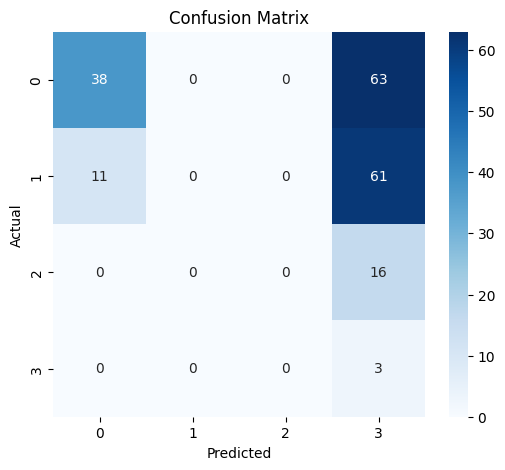

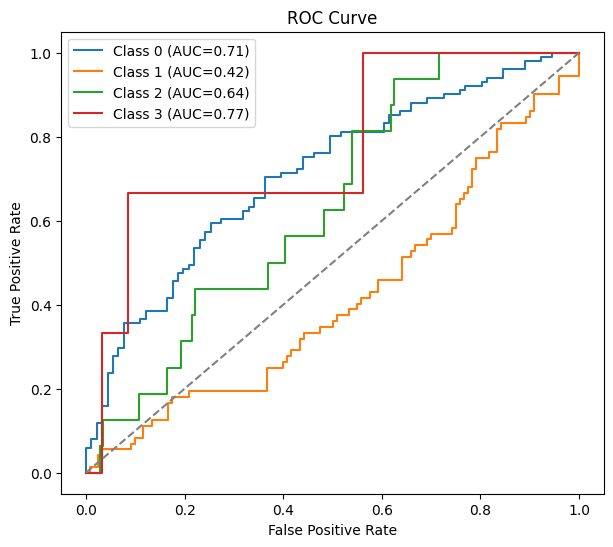

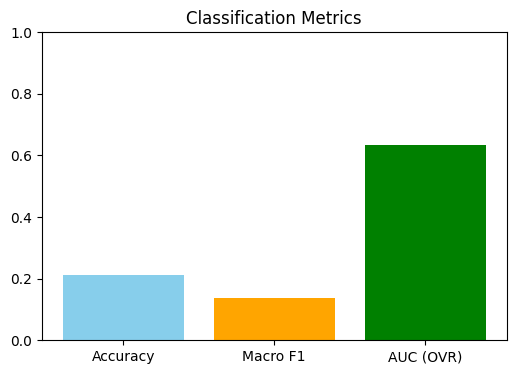

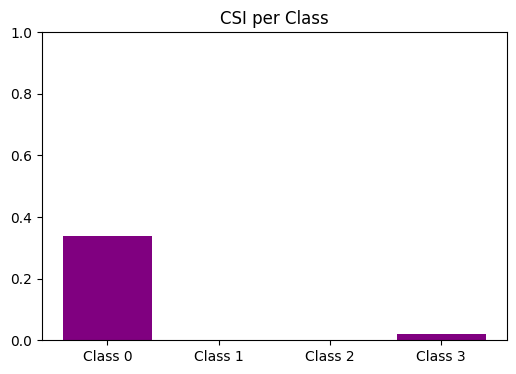

In [5]:
from tornadoq.train import train
from tornadoq.models import InitializeModel
from tornadoq.loadSaveEval import eval_model, save

# Choose model and hyperparameters
# model = "DNN"
# model = "StronglyEntangling"
model = "RandomLayer"
n_epochs = 2
lr = .01

# Initialize, train, and evaluate model
model = InitializeModel(model, load_path = None, classifier = classifier, input_size = 8)
print(type(model))
train(model = model, n_epochs = n_epochs, lr = lr, train_loader = train_loader, val_loader = val_loader, classifier = classifier)
eval_model(model = model, test_loader = test_loader, classifier = classifier)

# Training automatically saves the best performing model paramters
# Optionally, save the final model parameters
# save(model = model, save_path = None)
# Or load a previously trained model
# load(model = model, load_path = "")